In [1]:
import numpy as np
from matplotlib import pyplot as plt
from importlib import reload
from pathlib import Path

import qcodes as qc
from qcodes.dataset.sqlite.database import connect

from dataAnalysis.dataset import DataSet, FrequencyScanVNA, PowerScanVNA, BScanVNA
import dataAnalysis.plotting_functions as myplt

# DataSet

In [2]:
database_name = '2025_03_06_GaAs_W3Weg_JJ_3x2_LowFreq_circulator.db'
database_path = Path(r'C:\Users\fopplige\Documents\PhD\Data\ERiC\Data\qcodes_databases')

connection = connect(database_path / database_name)
exp = qc.load_experiment(1, conn=connection)

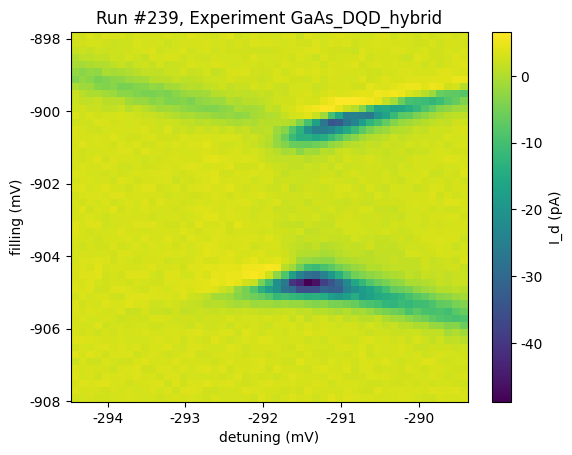

In [3]:
run_id = 239

ds = DataSet(exp=exp, run_id=run_id)
figs, axes, cbs = ds.plot('param_0')

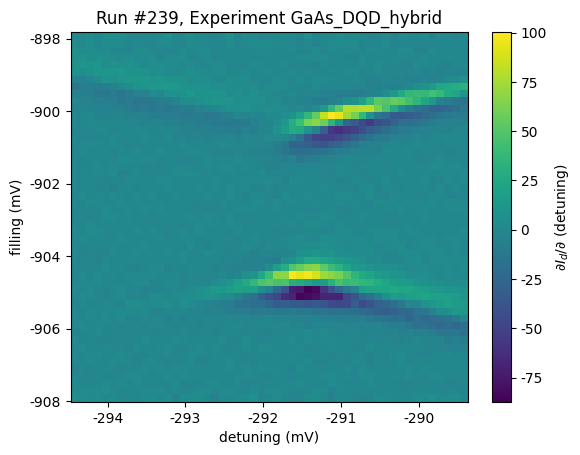

In [4]:
detuning = ds.get_independent_parameter_by_name('detuning')
filling = ds.get_dependent_parameter_by_name('filling')
ds.derive_data('param_0', axis=0)
figs, axes, cbs = ds.plot('param_0_derived')
myplt.format_colorbar(cbs[0], clabel=r'$\partial I_d / \partial$ (detuning)')

# FreqScanVNA

In [5]:
database_name = '2026_05_01_QT_hybrid_gen2_D6_D7.db'
database_path = Path(r'C:\Users\fopplige\Documents\PhD\Data\ERiC\Data\qcodes_databases')

connection = connect(database_path / database_name)
exp = qc.load_experiment(1, conn=connection)

c:\Users\fopplige\envs\analysis\Lib\site-packages\lmfit\model.py:1127: UserWarning: The keyword argument attenuation does not match any arguments of the model function. It will be ignored.
  warnings.warn(f"The keyword argument {name} does not " +


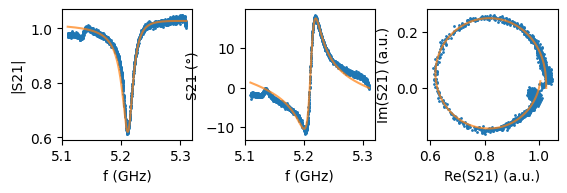

In [6]:
# extract data from the database
run_id = 560
ds = FrequencyScanVNA(exp, run_id=run_id)

# normalize the data to the background measurement
run_id_bg = 561
ds_bg = PowerScanVNA(exp, run_id=run_id_bg)
idx = -1
ds.normalize_data_vna(cData_bg=ds_bg.cData[:,idx], freq_bg=ds_bg.freq)

# fit the normalized data with lmfit and plot the results
ds.analyze(attenuation=95, method='lmfit', port_type='notch', do_plots=True, normalized=True)

In [7]:
ds.fit_report[0]['fitresults']

# PowerScanVNA

## Fit without nonlinearity

In [8]:
database_name = '2026_04_01_JJ_array_resonators_Si_new_Plassys.db'
database_path = Path(r'C:\Users\fopplige\Documents\PhD\Data\Lumi\QCoDeS_hqcpc6')

connection = connect(database_path / database_name)
exp = qc.load_experiment(1, conn=connection)

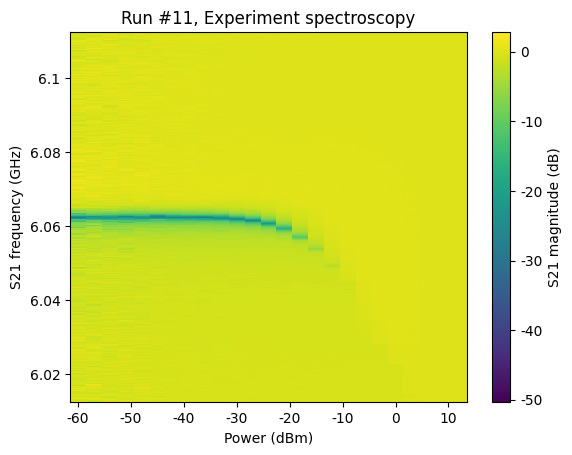

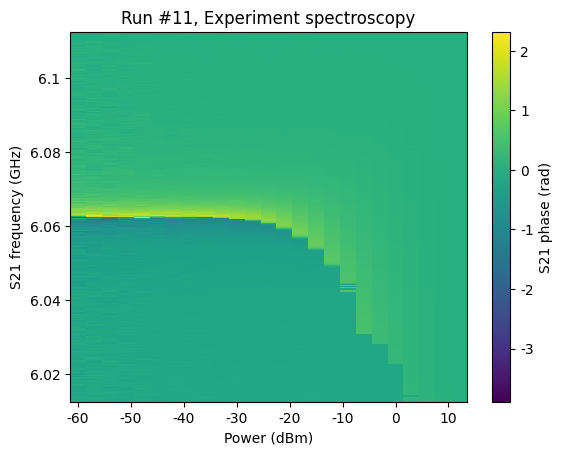

In [9]:
run_id = 11
p_range = [-60,-30]

ds = PowerScanVNA(exp, run_id=run_id)
ds.normalize_data_from_index()
ds.plot_normalized();

Power = -60.0 dBm


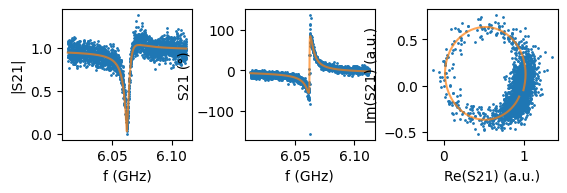

Power = -57.0 dBm


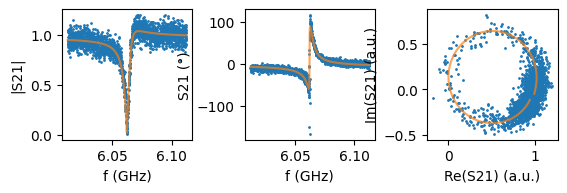

Power = -54.0 dBm


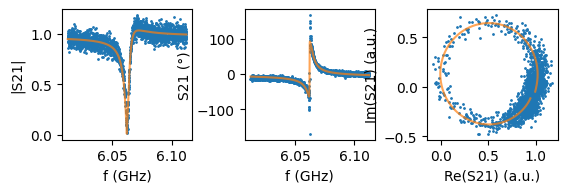

Power = -51.0 dBm


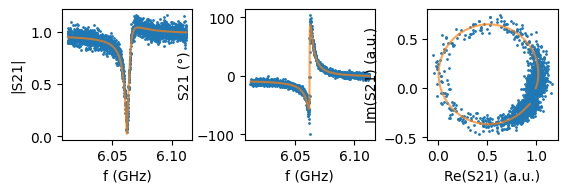

Power = -48.0 dBm


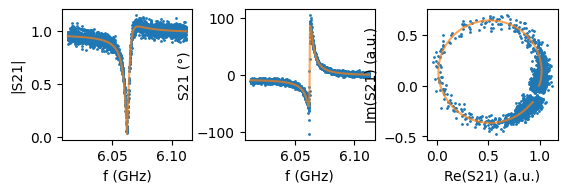

Power = -45.0 dBm


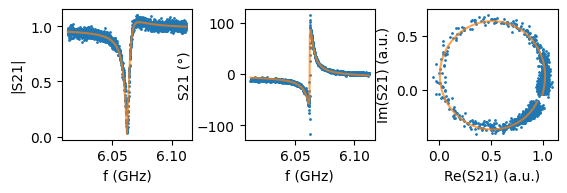

Power = -42.0 dBm


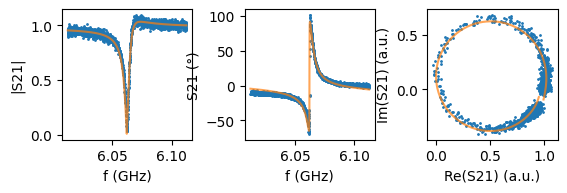

Power = -39.0 dBm


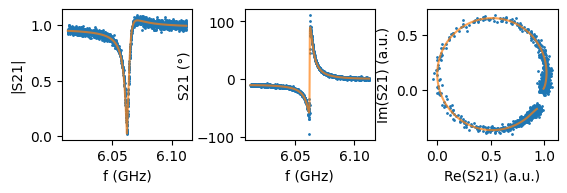

Power = -36.0 dBm


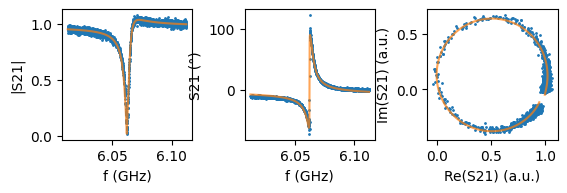

Power = -33.0 dBm


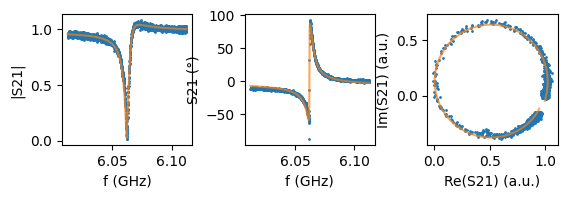

Power = -30.0 dBm


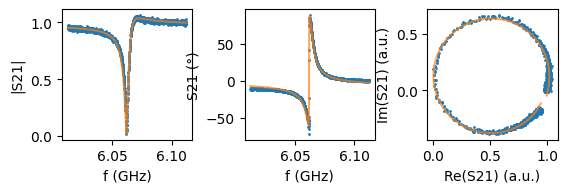

In [10]:
ds.analyze(power_range=p_range, attenuation=95, method='lmfit', port_type='notch', do_plots=True)

In [11]:
ds.fit_report['fitresults'][0]

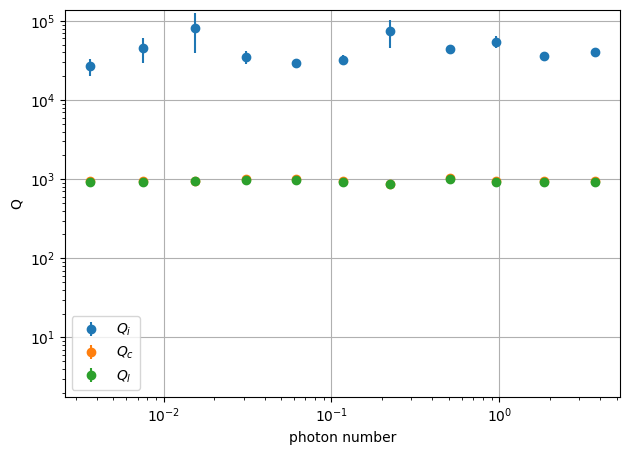

In [12]:
ds.plot_QvsP();

## Fit with nonlinearity

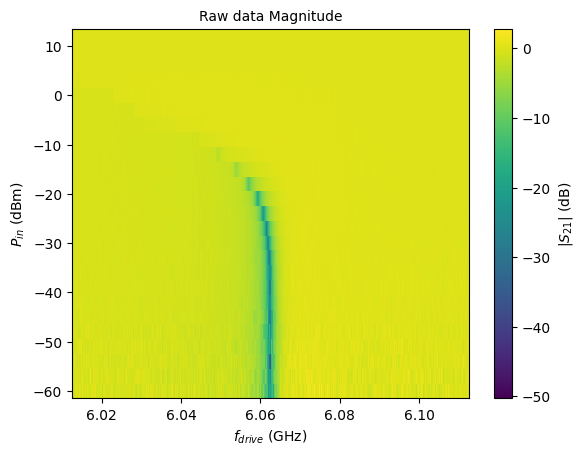

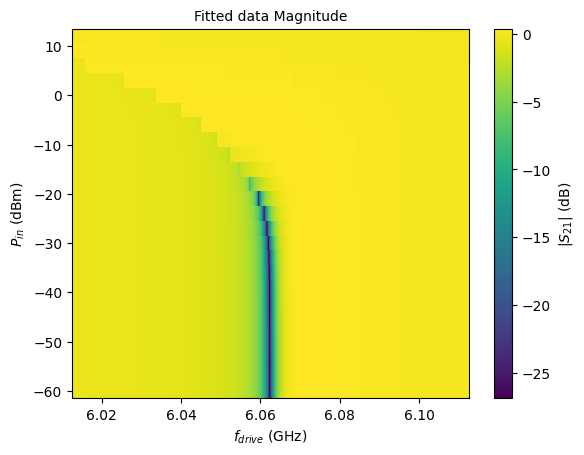

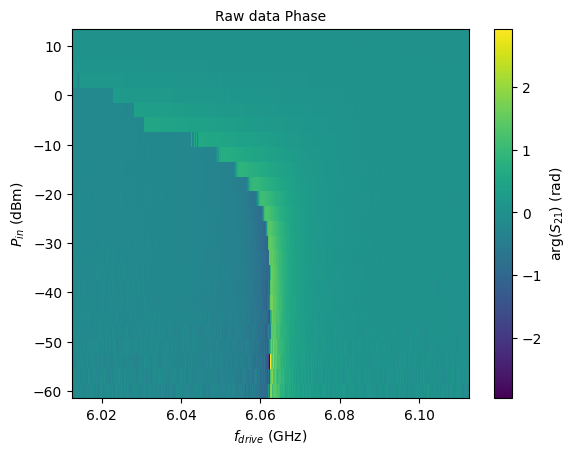

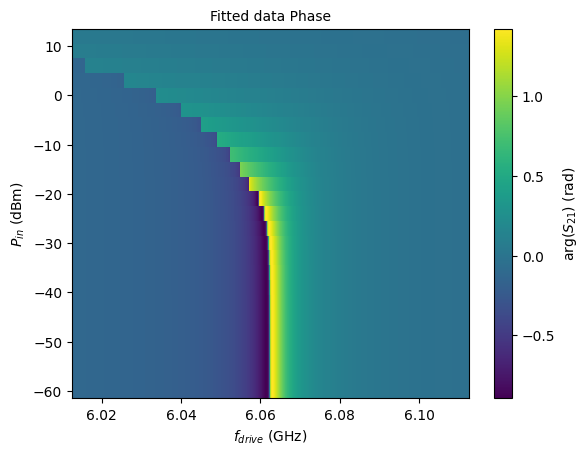

In [13]:
p_range = [-60,-52]
ds.analyze(power_range=p_range, attenuation=95, guesses={'Kerr': -10e3}, method='lmfit_nonlinear', port_type='notch', do_plots=True)

In [14]:
ds.fit_report['fitresults']

# BScanVNA

In [15]:
database_name = '2025_03_06_GaAs_W3Weg_JJ_3x2_LowFreq_circulator.db'
database_path = Path(r'C:\Users\fopplige\Documents\PhD\Data\ERiC\Data\qcodes_databases')

connection = connect(database_path / database_name)
exp = qc.load_experiment(1, conn=connection)

In [16]:
run_id = 893
ds = BScanVNA(exp=exp, run_id=run_id)
ds.normalize_data_from_index()

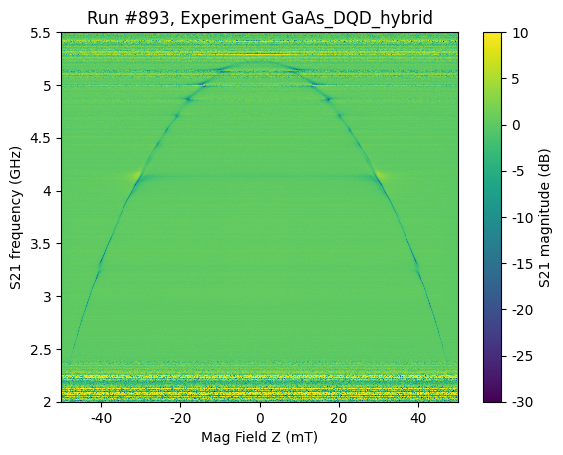

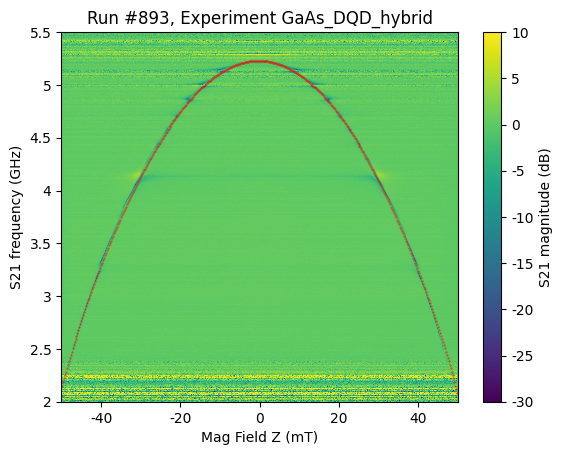

In [17]:
B0 = -0.25e-3 # in T
B_flux_quant = 58.5e-3 # in T
fmax = 5.23 # in GHz
freq_centers = ds.get_freq_centers_JJ(fmax, B_flux_quant, B0)
figs, axes, cbs = ds.plot('param_0_normalized', vmin=-30, vmax=10)
figs, axes, cbs = ds.plot('param_0_normalized', vmin=-30, vmax=10)
axes[0].plot(ds.field, freq_centers*1e9, c='r', ls='', marker='+', ms=2, alpha=0.5);

In [18]:
freq_span_fit = 0.5
input_power = -45 - 91.5
ds.analyze(freq_centers, freq_span=freq_span_fit, input_power=input_power,
               port_type='reflection', freq_unit='GHz', method='lmfit', do_plots=False, plot_initial_guesses=False)

In [19]:
ds.fit_report['fitresults'][100]

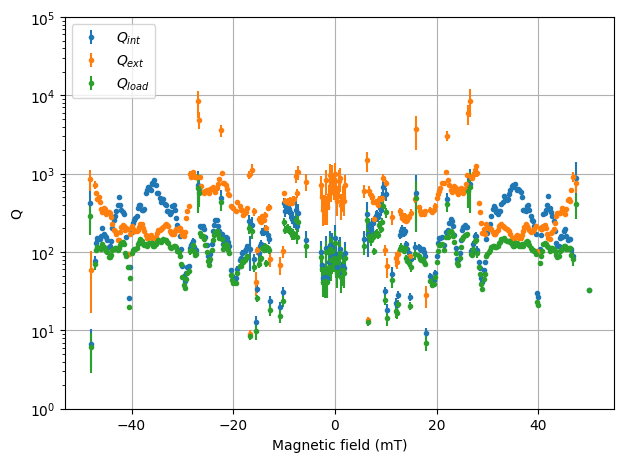

In [32]:
fig, ax = ds.plot_QvsB(threshold=1, ms=3);
ax.set_ylim(1e0, 1e5);